# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  

Person likely to live: 
    Miss. Mabel Helen Fortune, Age: 23, Sex: Female, Passenger Class: 1, Companions: 3, Embarked: Southampton, Fare: 263
    History Miss Fortune was being taken away for several monnths by her father to stiphle a relationship she was building with a Jazz musician whom she later marriedd. 
Person unlikely to live:
     Mr. David John	Barton, Age: 22, Sex: Male	Passenger Class: 3	Companios: 0 Embarked: Southampton, Fare: 8.05
     Mr. Barton was traveling to the US to begin a new life and to work for the major photography company Kodak. He origonally was supposed to travel with his friend on another ship, but his face had a blemish and he failed his medical test       due to it. 

In [3]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

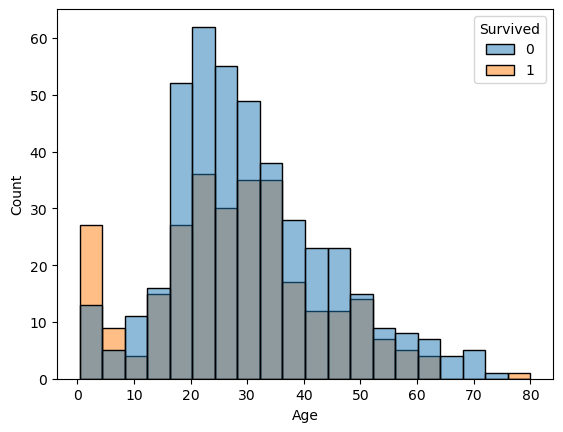

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.histplot(x='Age', data=df, hue='Survived')

plt.show()

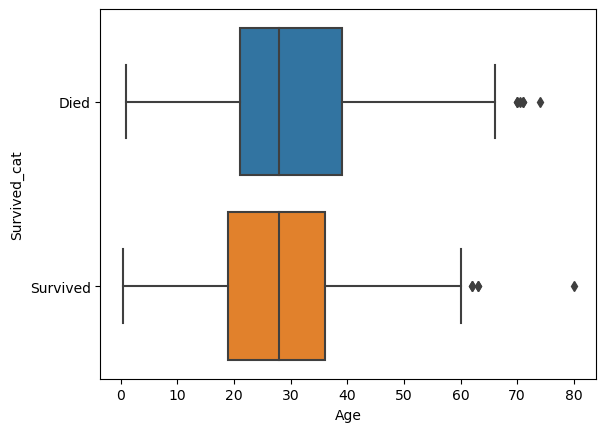

In [6]:
df.loc[df['Survived'] == 0, 'Survived_cat'] = 'Died'
df.loc[df['Survived'] == 1, 'Survived_cat'] = 'Survived'

sns.boxplot(x='Age', data=df, y='Survived_cat')
plt.show()

In [5]:
df['Survived'].dtype

dtype('int64')

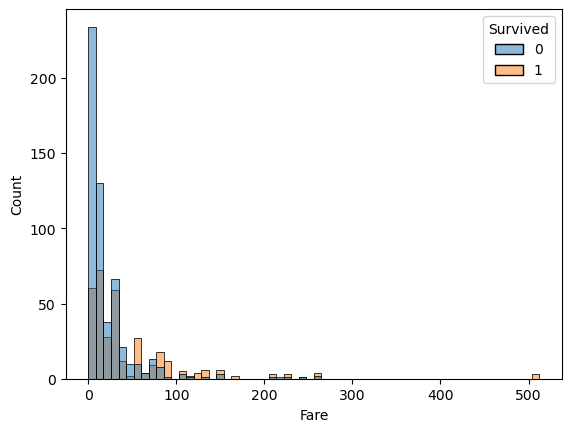

In [6]:
sns.histplot(x='Fare', data=df, hue='Survived')

plt.show()

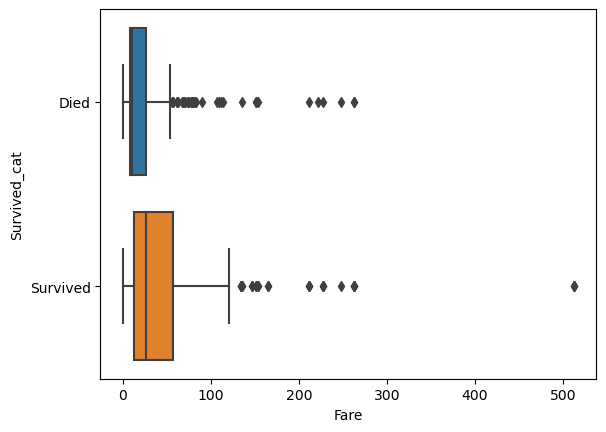

In [8]:
sns.boxplot(x='Fare', data=df, y='Survived_cat')

plt.show()

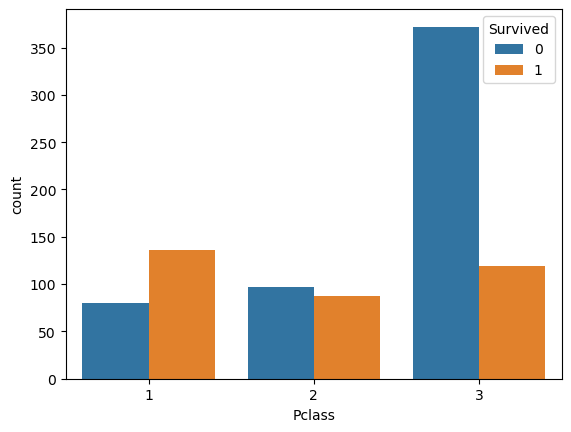

In [7]:
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.show()

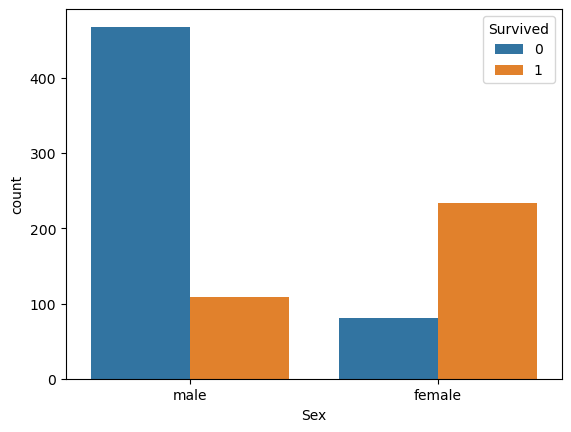

In [8]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.show()

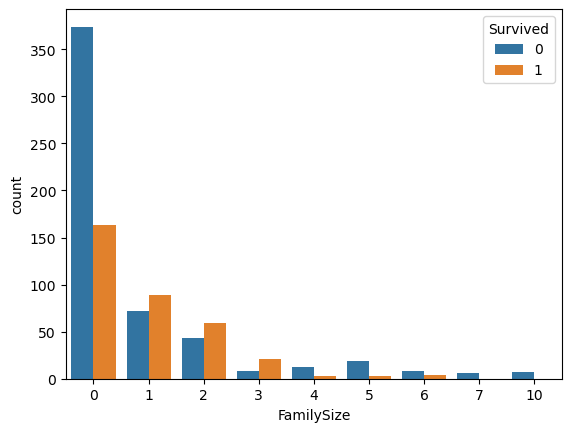

In [9]:
df['FamilySize'] = df['SibSp'] + df['Parch']
sns.countplot(data=df, x='FamilySize', hue='Survived')
plt.show()

In [22]:
likely = df.loc[(df['Sex']=='female') & 
                (df['Pclass']==1) & 
                (df['Age']>20) &
                (df['Survived']==1)]
unlikely = df.loc[(df['Sex']=='male') & 
                 (df['Pclass']==3) & 
                 (df['Age']>20) &
                 (df['Survived']==0)]

In [23]:
likely[['Name', 'Age', 'Sex', 'Pclass', 'SibSp', 'Parch', 'Embarked', 'Survived', 'Fare']].head(10)

,Name,Age,Sex,Pclass,SibSp,Parch,Embarked,Survived,Fare
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female,1,1,0,C,1,71.2833
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female,1,1,0,S,1,53.1000
11,"Bonnell, Miss. Elizabeth",58.0,female,1,0,0,S,1,26.5500
52,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",49.0,female,1,1,0,C,1,76.7292
61,"Icard, Miss. Amelie",38.0,female,1,0,0,NaN,1,80.0000
88,"Fortune, Miss. Mabel Helen",23.0,female,1,3,2,S,1,263.0000
151,"Pears, Mrs. Thomas (Edith Wearne)",22.0,female,1,1,0,S,1,66.6000
194,"Brown, Mrs. James Joseph (Margaret Tobin)",44.0,female,1,0,0,C,1,27.7208
195,"Lurette, Miss. Elise",58.0,female,1,0,0,C,1,146.5208
215,"Newell, Miss. Madeleine",31.0,female,1,1,0,C,1,113.2750


In [24]:
unlikely[['Name', 'Age', 'Sex', 'Pclass', 'SibSp', 'Parch', 'Embarked', 'Survived', 'Fare']].head(20)

,Name,Age,Sex,Pclass,SibSp,Parch,Embarked,Survived,Fare
0,"Braund, Mr. Owen Harris",22.0,male,3,1,0,S,0,7.2500
4,"Allen, Mr. William Henry",35.0,male,3,0,0,S,0,8.0500
13,"Andersson, Mr. Anders Johan",39.0,male,3,1,5,S,0,31.2750
37,"Cann, Mr. Ernest Charles",21.0,male,3,0,0,S,0,8.0500
51,"Nosworthy, Mr. Richard Cater",21.0,male,3,0,0,S,0,7.8000
57,"Novel, Mr. Mansouer",28.5,male,3,0,0,C,0,7.2292
60,"Sirayanian, Mr. Orsen",22.0,male,3,0,0,C,0,7.2292
69,"Kink, Mr. Vincenz",26.0,male,3,2,0,S,0,8.6625
73,"Chronopoulos, Mr. Apostolos",26.0,male,3,1,0,C,0,14.4542
75,"Moen, Mr. Sigurd Hansen",25.0,male,3,0,0,S,0,7.6500
